# Embedding Space Diagnostics

`Ai Slop, but pretty interesting one...`

**Purpose:** Validate two things before trusting SHAP results:

1. **Is the baseline realistic?** — Does mean/median sit in a low-density region of embedding space (the *"average of urban vs rural"* distortion problem)?
2. **Are target pairs outliers?** — How unusual is each pair relative to the full dataset?

**Standalone:** This notebook is fully self-contained. It loads the model, PCA, and data from scratch using the same config as nb1/nb2. No cells from other notebooks need to run first.

---
### Outputs
| File | What it shows |
|---|---|
| `diag_block_norms.png` | L2 norm distribution per block — is baseline norm realistic? |
| `diag_cosine_sim.png` | Cosine similarity to baseline — bimodal = baseline between two clusters |
| `diag_pca2d.png` | 2D projection — where is baseline relative to data cloud? |
| `diag_mahalanobis.png` | Mahalanobis outlier score in model PCA space |
| `diag_pred_distribution.png` | Where does f(baseline) sit among all model predictions? |

## Section 0 — Setup

In [ ]:
import os
os.chdir("/home/pcarrillo/PBI_XAI")  # ← adjust to your project root
print("Working directory:", os.getcwd())

FileNotFoundError: [Errno 2] No such file or directory: '/home/pcarrillo/PBI_XAI'

In [2]:
import os
import sys

# 1. Change the working directory to the project root
%cd ..

# 2. Add the root directory to the Python path so imports work
sys.path.append(os.getcwd())

# 3. Verify we are in the right place
print(f"Current Working Directory: {os.getcwd()}")
# !ls # Optional: list files to confirm you see 'main.py' and 'pbi_utils'p

/data/pavel.degterev/pbi
Current Working Directory: /data/pavel.degterev/pbi


In [3]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import yaml
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA as SkPCA

warnings.filterwarnings("ignore", category=UserWarning)
os.makedirs("XAI/results", exist_ok=True)
print(f"torch={torch.__version__}  numpy={np.__version__}")

torch=2.1.2+cu121  numpy=1.26.4


## Section 1 — Configuration

**Edit only this cell.** Everything else runs automatically.

In [17]:
# ── USER CONFIGURATION ─────────────────────────────────────────────────────
CONFIG_PATH   = "model_configs/best_model_XAI.yaml"
BASELINE_MODE = "median"   # "mean" | "median" | "random_sample"
RANDOM_SEED   = 48
N_BACKGROUND  = 100        # only used if BASELINE_MODE == "random_sample"
N_PROJ        = 1500        # max samples for 2D PCA plot (keep ≤500)

FILTERED_PAIRS = [
    {"id": 788,  "bacterium_id": 153,  "phage_id": 2014},
    {"id": 939,  "bacterium_id": 153,  "phage_id": 2153},
    {"id": 2271, "bacterium_id": 1869, "phage_id": 6187},
    {"id": 741,  "bacterium_id": 5859, "phage_id": 451},
    {"id": 728,  "bacterium_id": 5859, "phage_id": 5924},
    {"id": 768,  "bacterium_id": 5859, "phage_id": 5928},
]
DIAG_PAIRS = FILTERED_PAIRS  # set to a subset, e.g. FILTERED_PAIRS[:2]
# ───────────────────────────────────────────────────────────────────────────

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pair_colors = plt.cm.tab10(np.linspace(0, 0.6, len(DIAG_PAIRS)))
print(f"Device: {DEVICE}  |  Baseline: {BASELINE_MODE}  |  Pairs: {[p['id'] for p in DIAG_PAIRS]}") 

Device: cuda  |  Baseline: median  |  Pairs: [788, 939, 2271, 741, 728, 768]


## Section 2 — Block Definitions

Raw embedding layout in the 18824-dim concatenated vector:
- **Bacteria** (4036-dim): NT2 `[0:1536]`, MegaDNA `[1536:2500]`, DNABERT2 `[2500:4036]`
- **Phage** (14788-dim): NT2 `[4036:5572]`, MegaDNA `[5572:6536]`, DNABERT2 `[6536:18824]`

In [18]:
BACT_DIM = 4036
PHAG_DIM = 14788
FULL_DIM = BACT_DIM + PHAG_DIM  # 18824

BACT_BLOCKS = {
    "bact_NT2":      (0,    1536),
    "bact_MegaDNA":  (1536, 2500),
    "bact_DNABERT2": (2500, 4036),
}
PHAG_BLOCKS = {
    "phag_NT2":      (4036, 5572),
    "phag_MegaDNA":  (5572, 6536),
    "phag_DNABERT2": (6536, 18824),
}
BLOCKS = {**BACT_BLOCKS, **PHAG_BLOCKS}
BLOCK_NAMES = list(BLOCKS.keys())

print("Block layout:")
for i, (name, (s, e)) in enumerate(BLOCKS.items()):
    print(f"  [{i}] {name}: [{s}, {e})  width={e-s}")

Block layout:
  [0] bact_NT2: [0, 1536)  width=1536
  [1] bact_MegaDNA: [1536, 2500)  width=964
  [2] bact_DNABERT2: [2500, 4036)  width=1536
  [3] phag_NT2: [4036, 5572)  width=1536
  [4] phag_MegaDNA: [5572, 6536)  width=964
  [5] phag_DNABERT2: [6536, 18824)  width=12288


## Section 3 — Load Data, PCA, and Model

In [19]:
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)
print("Config:", cfg)

Config: {'input_perphect': {'bacteria_df': 'data/perphect-data/all/bacteria_df.csv', 'phages_df': 'data/perphect-data/all/phages_df.csv', 'couples_df': 'data/perphect-data/all-private-oversampled/couples_df.csv'}, 'embeddings_dir': 'data/embeddings', 'output_dir': 'output/best_model_XAI/', 'num_gpu': 1, 'gpu_id': 0, 'training_config': {'epochs': 100, 'learning_rate': '1e-3', 'weight_decay': '1e-4', 'batch_size': 256, 'reduce_dimensionality': 'PCA', 'n_components_bacteria': 500, 'n_components_phages': 500, 'k_folds_cv': 10}, 'phages_embedding_models': [{'name': 'NT2', 'params': {'model_name': 'nucleotide-transformer-v2-250m-multi-species'}, 'strategy': 'TopBottomTruncateStrategy', 'use_cached_embeddings': 'auto'}, {'name': 'MegaDNA', 'params': {'weights_path': 'data/weights/megaDNA_phage_145M.pt', 'get_layer': 'concat'}, 'strategy': 'MaxStrategy', 'use_cached_embeddings': 'auto'}, {'name': 'DNABERT2', 'params': {'source_code_path': 'DNABERT-2-117M/', 'max_seq_len': 32768}, 'strategy': '

In [7]:
from main import parse_config 

CONFIG_PATH = "model_configs/best_model_XAI.yaml"
config = parse_config(CONFIG_PATH)
DEVICE = config.device

[DEBUG] [NT2] Using InstaDeepAI default model weights
[DEBUG] [NT2] Max sequence length for Nucleotide Transformer: 12276
[DEBUG] [MegaDNA] Max sequence length for megaDNA: 131071
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 32768
[DEBUG] [NT2] Using InstaDeepAI default model weights
[DEBUG] [NT2] Max sequence length for Nucleotide Transformer: 12276
[DEBUG] [MegaDNA] Max sequence length for megaDNA: 131071
[DEBUG] [DNABERT2] Max sequence length for DNABERT2: 32768
[INFO] Configuration loaded from model_configs/best_model_XAI.yaml: Config(input_perphect=bacteria_df='data/perphect-data/all/bacteria_df.csv' phages_df='data/perphect-data/all/phages_df.csv' couples_df='data/perphect-data/all-private-oversampled/couples_df.csv', embeddings_dir=data/embeddings, num_gpu=1, gpu_id=0, training_config=TrainingConfig(do_train=True epochs=100 batch_size=256 learning_rate=0.001 weight_decay=0.0001 k_folds_cv=10 patience_early_stopping=1000 monitor_metric_early_stopping='f1' patience_reduce_

In [8]:
# ── Embedding test dataset ────────────────────────────────────────────────
emb_test_data = torch.load(config.test_path, map_location=DEVICE)
print(f"emb_test_data: {len(emb_test_data)} rows")
print(f"Columns: {list(emb_test_data.columns)}")
print(f"Label distribution:\n{emb_test_data['interaction_type'].value_counts()}")

emb_test_data: 1426 rows
Columns: ['id', 'phage_id', 'bacterium_id', 'interaction_type', 'bacterium_embedding', 'phage_embedding']
Label distribution:
interaction_type
0    1051
1     375
Name: count, dtype: int64


In [9]:
# ── PCA objects ───────────────────────────────────────────────────────────
with open(config.bacteria_pca_path, 'rb') as f:
    pca_bact = pickle.load(f)
#emb_test_data["bacterium_embedding"] = list(torch.from_numpy(pca_bact.transform(emb_test_data["bacterium_embedding"].apply(lambda x: x.detach().cpu().numpy()).to_list())).float())  # type: ignore

with open(config.phage_pca_path, 'rb') as f:
    pca_phag = pickle.load(f)
#emb_test_data["phage_embedding"] = list(torch.from_numpy(pca_phag.transform(emb_test_data["phage_embedding"].apply(lambda x: x.detach().cpu().numpy()).to_list())).float())  # type: ignore

print(f"pca_bact: {pca_bact.n_components_} components, input dim {pca_bact.n_features_in_}")
print(f"pca_phag: {pca_phag.n_components_} components, input dim {pca_phag.n_features_in_}")

pca_bact: 500 components, input dim 4036
pca_phag: 500 components, input dim 14788


In [10]:
# ── MLP classifier ────────────────────────────────────────────────────────
bacterium_embed_size = 500 #len(emb_test_data["bacterium_embedding"].iloc[0]) # always 500 ???
phage_embed_size = 500 #len(emb_test_data["phage_embedding"].iloc[0])
model = config.classifier(bacterium_embed_size, phage_embed_size, **config.classifier_params)

model.load_state_dict(torch.load(config.model_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print(f"Model loaded → {DEVICE}, eval mode.")

Model loaded → cuda:0, eval mode.


## Section 4 — Helper Functions and Baseline Construction

In [20]:
def tensor_to_numpy(t):
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy().astype(np.float64)
    return np.asarray(t, dtype=np.float64)

def mahal_diag(x, mean, std):
    """Diagonal Mahalanobis — exact after PCA decorrelation."""
    return float(np.sqrt(np.sum(((x - mean) / std) ** 2)))

def cosine_sim_to_vec(X_block, ref_vec):
    """Cosine similarity of each row in X_block to ref_vec. Returns (N,)."""
    dist = cdist(X_block.astype(np.float64), ref_vec.reshape(1, -1), metric="cosine").ravel()
    return 1.0 - dist

def get_pair_idx(pair, emb_test_data):
    row = emb_test_data.loc[emb_test_data["id"] == pair["id"]].iloc[0]
    return emb_test_data.index.get_loc(row.name)

In [21]:
def build_baseline(emb_test_data, mode, seed=42, n=100):
    """
    Build an 18824-dim baseline vector from unique organisms in emb_test_data.

    mode:
      'mean'          — component-wise mean over unique organisms.
      'median'        — component-wise median (more robust to outliers).
      'random_sample' — mean of n random samples (closest to E[f(X)]).

    The baseline is the SHAP reference point: SHAP values always sum to
    f(real_pair) − f(baseline). A baseline in a low-density region
    distorts individual contributions (see diagnostics below).
    """
    unique_bact = emb_test_data.drop_duplicates(subset="bacterium_id")
    unique_phag = emb_test_data.drop_duplicates(subset="phage_id")
    bact_stack  = np.stack([tensor_to_numpy(t) for t in unique_bact["bacterium_embedding"]])
    phag_stack  = np.stack([tensor_to_numpy(t) for t in unique_phag["phage_embedding"]])
    if mode == "mean":
        b, p = bact_stack.mean(0), phag_stack.mean(0)
    elif mode == "median":
        b, p = np.median(bact_stack, 0), np.median(phag_stack, 0)
    elif mode == "random_sample":
        rng  = np.random.default_rng(seed)
        b    = bact_stack[rng.integers(0, len(bact_stack), n)].mean(0)
        p    = phag_stack[rng.integers(0, len(phag_stack), n)].mean(0)
    else:
        raise ValueError(f"Unknown mode: {mode!r}")
    return np.concatenate([b, p]).astype(np.float64)

baseline_full = build_baseline(emb_test_data, BASELINE_MODE, RANDOM_SEED, N_BACKGROUND)
print(f"Baseline built — mode={BASELINE_MODE!r}, shape={baseline_full.shape}")
print(f"  bact norm: {np.linalg.norm(baseline_full[:BACT_DIM]):.4f}")
print(f"  phag norm: {np.linalg.norm(baseline_full[BACT_DIM:]):.4f}")

Baseline built — mode='median', shape=(18824,)
  bact norm: 16.3534
  phag norm: 16.8386


## Section 5 — Build Raw Embedding Matrix

In [22]:
bact_arrs = np.stack([tensor_to_numpy(t) for t in emb_test_data["bacterium_embedding"]])
phag_arrs = np.stack([tensor_to_numpy(t) for t in emb_test_data["phage_embedding"]])
X_raw     = np.concatenate([bact_arrs, phag_arrs], axis=1)
assert X_raw.shape[1] == FULL_DIM, f"Expected {FULL_DIM} cols, got {X_raw.shape[1]}"

bact_side     = X_raw[:, :BACT_DIM]
phag_side     = X_raw[:, BACT_DIM:]
baseline_bact = baseline_full[:BACT_DIM]
baseline_phag = baseline_full[BACT_DIM:]

print(f"X_raw:      {X_raw.shape}")
print(f"bact_side:  {bact_side.shape}")
print(f"phag_side:  {phag_side.shape}")

X_raw:      (1426, 18824)
bact_side:  (1426, 4036)
phag_side:  (1426, 14788)


## Section 6 — Block L2 Norm Distributions

For each block, the L2 norm summarises "how large is this model's output for this sample" in a single scalar.

**How to read:**
- Histogram = full dataset distribution of norms.
- Red line = your baseline's norm. If it is outside the shaded IQR → baseline is in a low-density region for this block.
- Blue dashed = dataset median, orange dashed = mean.
- Dotted coloured lines = target pairs.

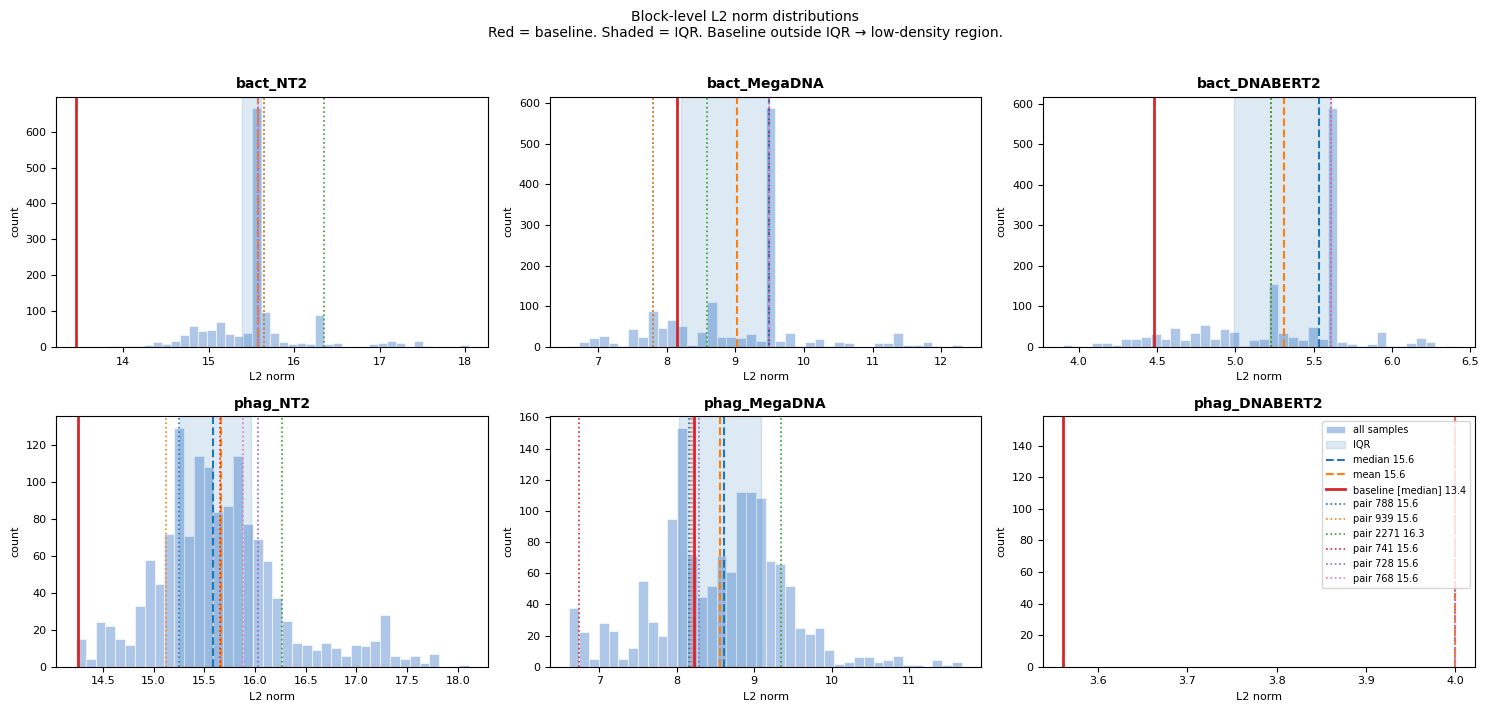

Saved: XAI/results/diag_block_norms.png


In [23]:
norms_all = pd.DataFrame(
    {name: np.linalg.norm(X_raw[:, s:e], axis=1) for name, (s, e) in BLOCKS.items()}
)
baseline_norms = {name: float(np.linalg.norm(baseline_full[s:e]))
                  for name, (s, e) in BLOCKS.items()}
pair_norms = {}
for pair in DIAG_PAIRS:
    idx = get_pair_idx(pair, emb_test_data)
    pair_norms[pair["id"]] = {
        name: float(np.linalg.norm(X_raw[idx, s:e]))
        for name, (s, e) in BLOCKS.items()
    }

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for ax, (name, (s, e)) in zip(axes, BLOCKS.items()):
    vals = norms_all[name].values
    q25, q50, q75 = np.percentile(vals, [25, 50, 75])
    ax.hist(vals, bins=40, color="#aec6e8", edgecolor="white", lw=0.4, label="all samples")
    ax.axvspan(q25, q75, alpha=0.15, color="#1f77b4", label="IQR")
    ax.axvline(q50,                  color="#1f77b4", lw=1.5, ls="--", label=f"median {q50:.1f}")
    ax.axvline(vals.mean(),          color="#ff7f0e", lw=1.5, ls="--", label=f"mean {vals.mean():.1f}")
    ax.axvline(baseline_norms[name], color="#d62728", lw=2,   ls="-",
               label=f"baseline [{BASELINE_MODE}] {baseline_norms[name]:.1f}")
    for pair, color in zip(DIAG_PAIRS, pair_colors):
        pn = pair_norms[pair["id"]][name]
        ax.axvline(pn, color=color, lw=1.2, ls=":", label=f"pair {pair['id']} {pn:.1f}")
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("L2 norm", fontsize=8)
    ax.set_ylabel("count", fontsize=8)
    ax.tick_params(labelsize=8)
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize=7, loc="upper right")
fig.suptitle("Block-level L2 norm distributions\nRed = baseline. Shaded = IQR. Baseline outside IQR → low-density region.",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig("XAI/results/diag_block_norms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: XAI/results/diag_block_norms.png")

In [46]:
# ── Diagnostic print — run this before the plot cell ─────────────────────
print("=== Block norm ranges ===")
for name, (s, e) in BLOCKS.items():
    vals = norms_all[name].values
    bl   = baseline_norms[name]
    print(f"{name:20s}  data: [{vals.min():.2f}, {vals.max():.2f}]  "
          f"median={np.median(vals):.2f}  baseline={bl:.2f}")

print("\n=== Target pair norms (first pair only) ===")
pair = DIAG_PAIRS[0]
for name in BLOCKS:
    pn = pair_norms[pair["id"]][name]
    print(f"  {name:20s}  {pn:.4f}")

print("\n=== 6th subplot (axes[-1]) gets the legend — check it has data ===")
last_name = list(BLOCKS.keys())[-1]
last_s, last_e = BLOCKS[last_name]
print(f"Last block: {last_name}  [{last_s}:{last_e}]")
print(f"  data range: {norms_all[last_name].values.min():.4f} – {norms_all[last_name].values.max():.4f}")

=== Block norm ranges ===
bact_NT2              data: [13.82, 18.04]  median=15.58  baseline=13.45
bact_MegaDNA          data: [6.58, 12.30]  median=9.49  baseline=8.15
bact_DNABERT2         data: [3.90, 6.40]  median=5.54  baseline=4.48
phag_NT2              data: [14.24, 18.11]  median=15.58  baseline=14.26
phag_MegaDNA          data: [6.61, 11.68]  median=8.61  baseline=8.22
phag_DNABERT2         data: [4.00, 4.00]  median=4.00  baseline=3.56

=== Target pair norms (first pair only) ===
  bact_NT2              15.6478
  bact_MegaDNA          7.7995
  bact_DNABERT2         5.2310
  phag_NT2              15.2515
  phag_MegaDNA          8.1547
  phag_DNABERT2         4.0000

=== 6th subplot (axes[-1]) gets the legend — check it has data ===
Last block: phag_DNABERT2  [6536:18824]
  data range: 4.0000 – 4.0000


## Section 7 — Cosine Similarity to Baseline

How similar (direction-wise) is each sample to the baseline vector, per block?

**How to read:**
- Bell curve near 1.0 → baseline is a natural centre.
- **Bimodal** → baseline sits between two clusters — the "urban vs rural" problem. Switch baseline mode if you see this.
- Left-skewed → most samples are directionally far from baseline → baseline may be noise.

/tmp/ipykernel_2785605/879122948.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sim_p = float(cosine_sim_to_vec(X_raw[idx, s:e].reshape(1, -1), baseline_full[s:e]))


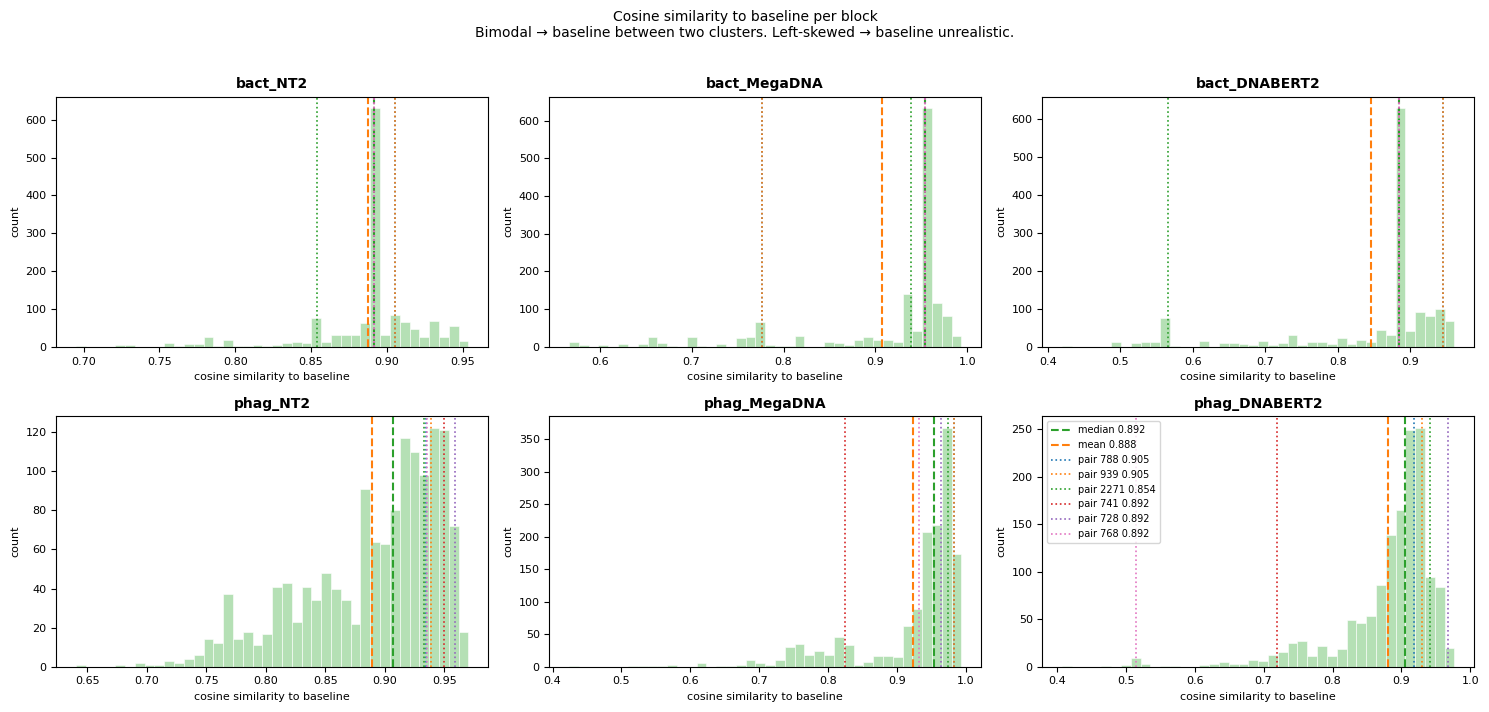

Saved: XAI/results/diag_cosine_sim.png


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for ax, (name, (s, e)) in zip(axes, BLOCKS.items()):
    sims = cosine_sim_to_vec(X_raw[:, s:e], baseline_full[s:e])
    ax.hist(sims, bins=40, color="#b5e0b5", edgecolor="white", lw=0.4)
    ax.axvline(np.median(sims), color="#2ca02c", lw=1.5, ls="--", label=f"median {np.median(sims):.3f}")
    ax.axvline(sims.mean(),     color="#ff7f0e", lw=1.5, ls="--", label=f"mean {sims.mean():.3f}")
    for pair, color in zip(DIAG_PAIRS, pair_colors):
        idx   = get_pair_idx(pair, emb_test_data)
        sim_p = float(cosine_sim_to_vec(X_raw[idx, s:e].reshape(1, -1), baseline_full[s:e]))
        ax.axvline(sim_p, color=color, lw=1.2, ls=":", label=f"pair {pair['id']} {sim_p:.3f}")
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("cosine similarity to baseline", fontsize=8)
    ax.set_ylabel("count", fontsize=8)
    ax.tick_params(labelsize=8)
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize=7)
fig.suptitle("Cosine similarity to baseline per block\nBimodal → baseline between two clusters. Left-skewed → baseline unrealistic.",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig("XAI/results/diag_cosine_sim.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: XAI/results/diag_cosine_sim.png")

## Section 8 — 2D PCA Projection

Project bacteria and phage embeddings into 2D to visually inspect where the baseline and target pairs sit relative to the data cloud. Uses a fresh 2-component PCA (visualisation only — separate from the model's 500-component PCA).

**How to read:**
- Grey/blue dots = dataset samples.
- ★ (red star) = baseline. Should be inside or near the data cloud.
- ◆ = dataset mean (orange) and median (blue).
- ▲ = target pairs. Far from the cloud = genuine embedding outlier.

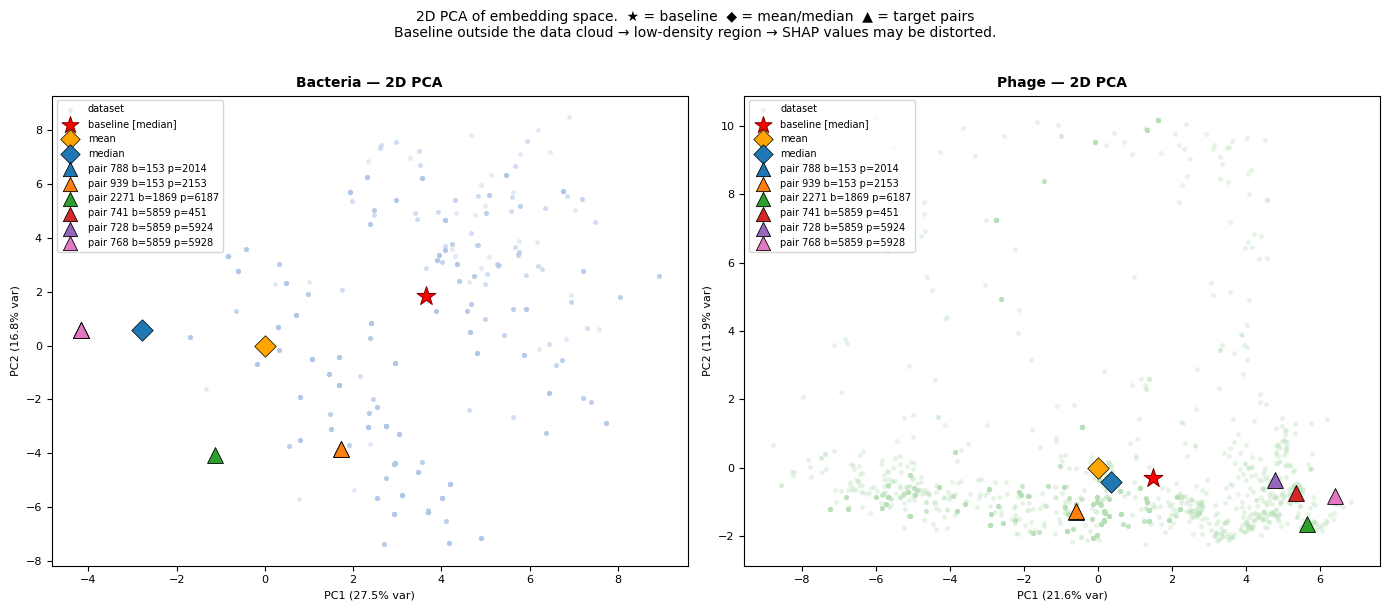

Saved: XAI/results/diag_pca2d.png


In [25]:
def pca_2d_plot(ax, X_side, baseline_side, pair_vecs, pair_labels, pair_colors, title, dot_color):
    rng   = np.random.default_rng(RANDOM_SEED)
    n     = min(N_PROJ, len(X_side))
    idx_s = rng.choice(len(X_side), n, replace=False)
    pca2  = SkPCA(n_components=2, random_state=RANDOM_SEED)
    X_sub = X_side[idx_s]
    pca2.fit(X_sub)
    proj_all  = pca2.transform(X_sub)
    proj_bl   = pca2.transform(baseline_side.reshape(1, -1))
    proj_mean = pca2.transform(X_side.mean(0).reshape(1, -1))
    proj_med  = pca2.transform(np.median(X_side, 0).reshape(1, -1))
    ax.scatter(proj_all[:,0], proj_all[:,1], c=dot_color, alpha=0.25, s=7, label="dataset", zorder=1)
    ax.scatter(proj_bl[0,0],   proj_bl[0,1],   c="red",     s=200, marker="*", zorder=6,
               label=f"baseline [{BASELINE_MODE}]", edgecolors="darkred", lw=0.8)
    ax.scatter(proj_mean[0,0], proj_mean[0,1], c="orange",  s=120, marker="D", zorder=5,
               label="mean", edgecolors="black", lw=0.5)
    ax.scatter(proj_med[0,0],  proj_med[0,1],  c="#1f77b4", s=120, marker="D", zorder=5,
               label="median", edgecolors="black", lw=0.5)
    for vec, lbl, color in zip(pair_vecs, pair_labels, pair_colors):
        proj_p = pca2.transform(vec.reshape(1, -1))
        ax.scatter(proj_p[0,0], proj_p[0,1], c=[color], s=130, marker="^", zorder=7,
                   edgecolors="black", lw=0.6, label=lbl)
    ev = pca2.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}% var)", fontsize=8)
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}% var)", fontsize=8)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7, markerscale=0.9)
    ax.tick_params(labelsize=8)

pair_bact_vecs, pair_phag_vecs, pair_plot_labels = [], [], []
for pair in DIAG_PAIRS:
    idx = get_pair_idx(pair, emb_test_data)
    pair_bact_vecs.append(X_raw[idx, :BACT_DIM])
    pair_phag_vecs.append(X_raw[idx, BACT_DIM:])
    pair_plot_labels.append(f"pair {pair['id']} b={pair['bacterium_id']} p={pair['phage_id']}")

fig, (ax_b, ax_p) = plt.subplots(1, 2, figsize=(14, 6))
pca_2d_plot(ax_b, bact_side, baseline_bact, pair_bact_vecs, pair_plot_labels, pair_colors,
            "Bacteria — 2D PCA", "#aec6e8")
pca_2d_plot(ax_p, phag_side, baseline_phag, pair_phag_vecs, pair_plot_labels, pair_colors,
            "Phage — 2D PCA", "#b5e0b5")
fig.suptitle("2D PCA of embedding space.  ★ = baseline  ◆ = mean/median  ▲ = target pairs\n"
             "Baseline outside the data cloud → low-density region → SHAP values may be distorted.",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig("XAI/results/diag_pca2d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: XAI/results/diag_pca2d.png")

## Section 9 — Mahalanobis Outlier Score (Model PCA Space)

Mahalanobis distance accounts for the covariance structure of the data. We compute it in the model's 500-dim PCA space because:
- The 18k-dim covariance matrix is singular (not invertible).
- After PCA, components are decorrelated so diagonal Mahalanobis is exact.
- This is the space the model actually operates in.

**How to read:**
- Distribution = all test samples. Red line = baseline. Dashed = target pairs.
- **Baseline >80th percentile** → baseline is in a low-density region → consider switching baseline mode.
- **Pair >90th percentile** → genuine outlier → note this when reporting SHAP results for that pair.

[ 4.75362343  4.75362343 13.82081814 ... 14.97763283  1.46692674
 16.1280713 ]
[21.98614852 36.83781449 10.83630044 ...  9.33029326 23.74747624
 11.11174906]


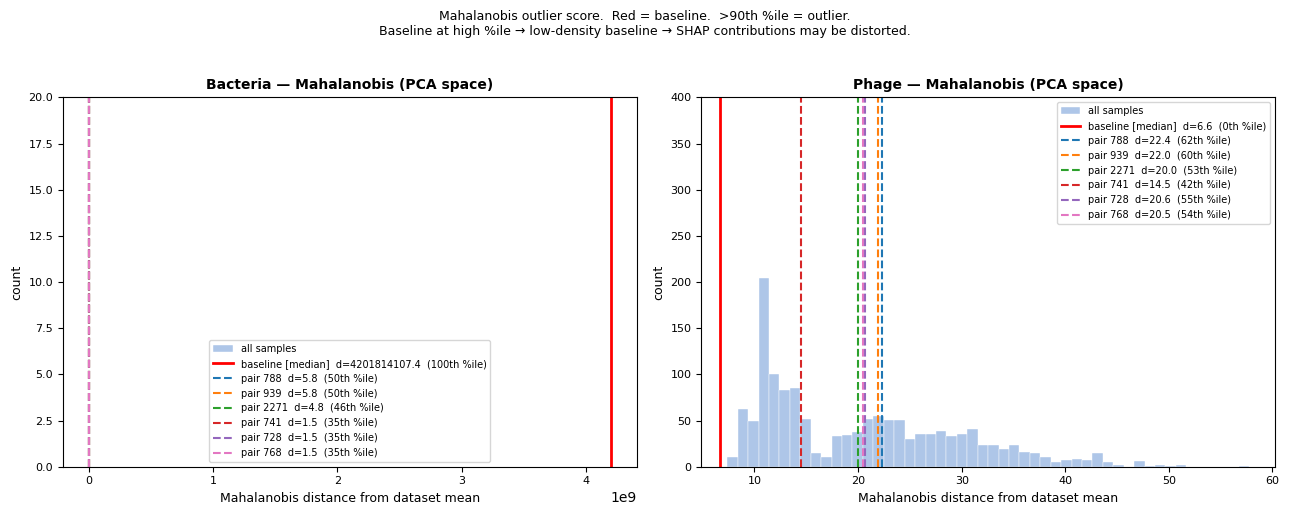

Saved: XAI/results/diag_mahalanobis.png


In [44]:
X_pca_bact = pca_bact.transform(bact_side.astype(np.float64))
X_pca_phag = pca_phag.transform(phag_side.astype(np.float64))
bl_pca_b   = pca_bact.transform(baseline_bact.reshape(1, -1))
bl_pca_p   = pca_phag.transform(baseline_phag.reshape(1, -1))

mean_b, std_b = X_pca_bact.mean(0), X_pca_bact.std(0) + 1e-10
mean_p, std_p = X_pca_phag.mean(0), X_pca_phag.std(0) + 1e-10

mahal_all_b = np.array([mahal_diag(X_pca_bact[i], mean_b, std_b) for i in range(len(X_pca_bact))])
mahal_all_p = np.array([mahal_diag(X_pca_phag[i], mean_p, std_p) for i in range(len(X_pca_phag))])
mahal_bl_b  = mahal_diag(bl_pca_b[0], mean_b, std_b)
mahal_bl_p  = mahal_diag(bl_pca_p[0], mean_p, std_p)

pair_mahal = []
for pair in DIAG_PAIRS:
    idx = get_pair_idx(pair, emb_test_data)
    mb  = mahal_diag(X_pca_bact[idx], mean_b, std_b)
    mp  = mahal_diag(X_pca_phag[idx], mean_p, std_p)
    pair_mahal.append({
        "pair_id": pair["id"],
        "bact_mahal": mb, "phag_mahal": mp,
        "bact_pctile": np.mean(mahal_all_b <= mb)*100,
        "phag_pctile": np.mean(mahal_all_p <= mp)*100,
    })

fig, (ax_b, ax_p) = plt.subplots(1, 2, figsize=(13, 5))
for num, ax, mahal_all, mahal_bl, rows_key, label in [
    (20, ax_b, mahal_all_b, mahal_bl_b, "bact_mahal", "Bacteria"),
    (400, ax_p, mahal_all_p, mahal_bl_p, "phag_mahal", "Phage"),
]:
    pct_bl = np.mean(mahal_all <= mahal_bl)*100
    ax.hist(mahal_all, bins=50, color="#aec6e8", edgecolor="white", lw=0.3, label="all samples")
    ax.axvline(mahal_bl, color="red", lw=2,
               label=f"baseline [{BASELINE_MODE}]  d={mahal_bl:.1f}  ({pct_bl:.0f}th %ile)")
    for pair, color, row in zip(DIAG_PAIRS, pair_colors, pair_mahal):
        d   = row[rows_key]
        pct = row[rows_key.replace("mahal","pctile")]
        ax.axvline(d, color=color, lw=1.5, ls="--",
                   label=f"pair {pair['id']}  d={d:.1f}  ({pct:.0f}th %ile)")
    
    ax.set_ylim(0, num)
    print(mahal_all)

    ax.set_xlabel("Mahalanobis distance from dataset mean", fontsize=9)
    ax.set_ylabel("count", fontsize=9)
    ax.set_title(f"{label} — Mahalanobis (PCA space)", fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)
fig.suptitle("Mahalanobis outlier score.  Red = baseline.  >90th %ile = outlier.\n"
             "Baseline at high %ile → low-density baseline → SHAP contributions may be distorted.",
             fontsize=9, y=1.02)
plt.tight_layout()
plt.savefig("XAI/results/diag_mahalanobis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: XAI/results/diag_mahalanobis.png")

In [32]:
counts.max()

368

In [37]:
mahal_bl_b

4201814107.3568697

bact Mahal range: 1.42 – 71.72  median=5.51
phag Mahal range: 7.65 – 68.48  median=21.56
baseline bact: 8.88  phag: 7.83


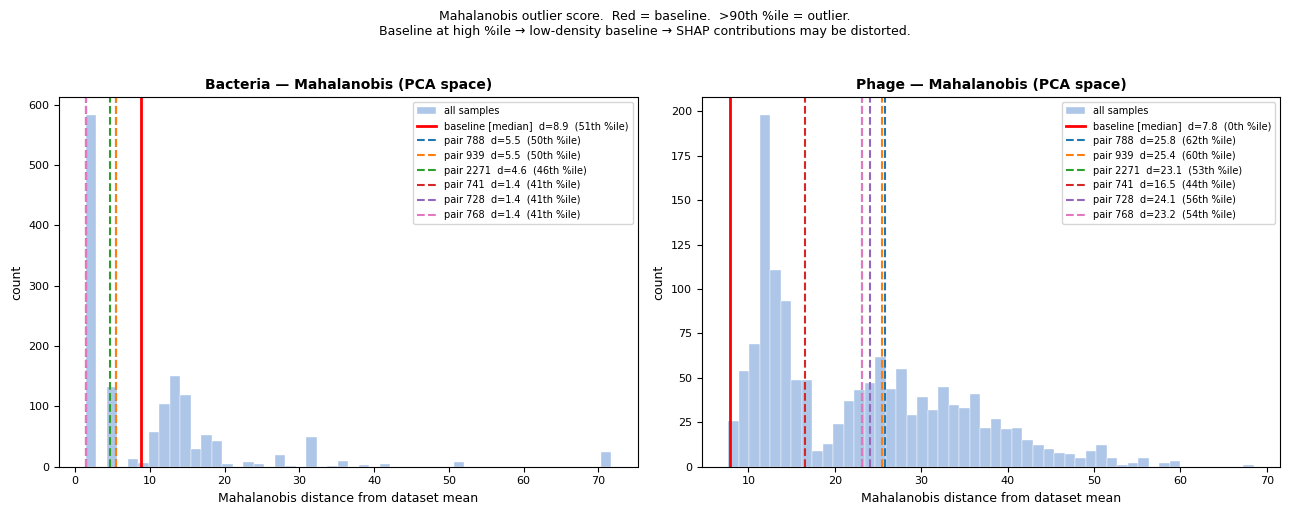

In [45]:
# ── Mahalanobis in PCA space — corrected ─────────────────────────────────

X_pca_bact = pca_bact.transform(bact_side.astype(np.float64))
X_pca_phag = pca_phag.transform(phag_side.astype(np.float64))
bl_pca_b   = pca_bact.transform(baseline_bact.reshape(1, -1))
bl_pca_p   = pca_phag.transform(baseline_phag.reshape(1, -1))

def mahal_pca(X_proj, x_query, pca_obj, var_floor=1e-6):
    """
    Proper Mahalanobis distance in PCA space.
    
    Uses the PCA's own explained_variance_ (eigenvalues of the covariance 
    matrix) instead of recomputing std from projected data. This is exact:
    after PCA, component k has variance = pca.explained_variance_[k].
    
    var_floor: ignore components whose variance is below this threshold.
    These are near-zero-variance directions where division becomes unstable.
    """
    variances  = pca_obj.explained_variance_          # shape (n_components,)
    keep       = variances > var_floor                 # boolean mask
    mean_proj  = X_proj[:, keep].mean(axis=0)         # centre in kept dims
    x_centered = (x_query[keep] - mean_proj)          # distance from centre
    return float(np.sqrt(np.sum((x_centered ** 2) / variances[keep])))

# Compute for all test samples
mean_pca_b = X_pca_bact.mean(axis=0)
mean_pca_p = X_pca_phag.mean(axis=0)

mahal_all_b = np.array([
    mahal_pca(X_pca_bact, X_pca_bact[i], pca_bact)
    for i in range(len(X_pca_bact))
])
mahal_all_p = np.array([
    mahal_pca(X_pca_phag, X_pca_phag[i], pca_phag)
    for i in range(len(X_pca_phag))
])

# Baseline
mahal_bl_b = mahal_pca(X_pca_bact, bl_pca_b[0], pca_bact)
mahal_bl_p = mahal_pca(X_pca_phag, bl_pca_p[0], pca_phag)

# Target pairs
pair_mahal = []
for pair in DIAG_PAIRS:
    idx = get_pair_idx(pair, emb_test_data)
    mb  = mahal_pca(X_pca_bact, X_pca_bact[idx], pca_bact)
    mp  = mahal_pca(X_pca_phag, X_pca_phag[idx], pca_phag)
    pair_mahal.append({
        "pair_id":     pair["id"],
        "bact_mahal":  mb,
        "phag_mahal":  mp,
        "bact_pctile": np.mean(mahal_all_b <= mb) * 100,
        "phag_pctile": np.mean(mahal_all_p <= mp) * 100,
    })

# Quick sanity check — print range before plotting
print(f"bact Mahal range: {mahal_all_b.min():.2f} – {mahal_all_b.max():.2f}  "
      f"median={np.median(mahal_all_b):.2f}")
print(f"phag Mahal range: {mahal_all_p.min():.2f} – {mahal_all_p.max():.2f}  "
      f"median={np.median(mahal_all_p):.2f}")
print(f"baseline bact: {mahal_bl_b:.2f}  phag: {mahal_bl_p:.2f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, (ax_b, ax_p) = plt.subplots(1, 2, figsize=(13, 5))
for ax, mahal_all, mahal_bl, rows_key, label in [
    (ax_b, mahal_all_b, mahal_bl_b, "bact_mahal", "Bacteria"),
    (ax_p, mahal_all_p, mahal_bl_p, "phag_mahal", "Phage"),
]:
    pct_bl = np.mean(mahal_all <= mahal_bl) * 100
    ax.hist(mahal_all, bins=50, color="#aec6e8", edgecolor="white", lw=0.3,
            label="all samples")
    ax.axvline(mahal_bl, color="red", lw=2,
               label=f"baseline [{BASELINE_MODE}]  d={mahal_bl:.1f}  ({pct_bl:.0f}th %ile)")
    for pair, color, row in zip(DIAG_PAIRS, pair_colors, pair_mahal):
        d   = row[rows_key]
        pct = row[rows_key.replace("mahal", "pctile")]
        ax.axvline(d, color=color, lw=1.5, ls="--",
                   label=f"pair {pair['id']}  d={d:.1f}  ({pct:.0f}th %ile)")
    # No manual set_ylim — let matplotlib choose from the actual data
    ax.set_xlabel("Mahalanobis distance from dataset mean", fontsize=9)
    ax.set_ylabel("count", fontsize=9)
    ax.set_title(f"{label} — Mahalanobis (PCA space)", fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

fig.suptitle(
    "Mahalanobis outlier score.  Red = baseline.  >90th %ile = outlier.\n"
    "Baseline at high %ile → low-density baseline → SHAP contributions may be distorted.",
    fontsize=9, y=1.02
)
plt.tight_layout()
plt.savefig("XAI/results/diag_mahalanobis.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 10 — Prediction Score Distribution

Where does `f(baseline)` sit among all model predictions?

All SHAP values sum to `f(pair) − f(baseline)`. If `f(baseline)` is far from the dataset mean prediction, your SHAP reference point is unusual — contributions are attributed relative to an atypical starting point.

**How to read:**
- Blue histogram = non-interacting pairs (label=0).
- Red histogram = interacting pairs (label=1).
- Red vertical line = `f(baseline)` — the SHAP reference. Should ideally sit near the centre of the full distribution.
- Gap between `f(baseline)` and dataset mean prediction > 0.15 → consider switching to `random_sample` baseline.

Computing predictions for full test set (batched, no SHAP)...


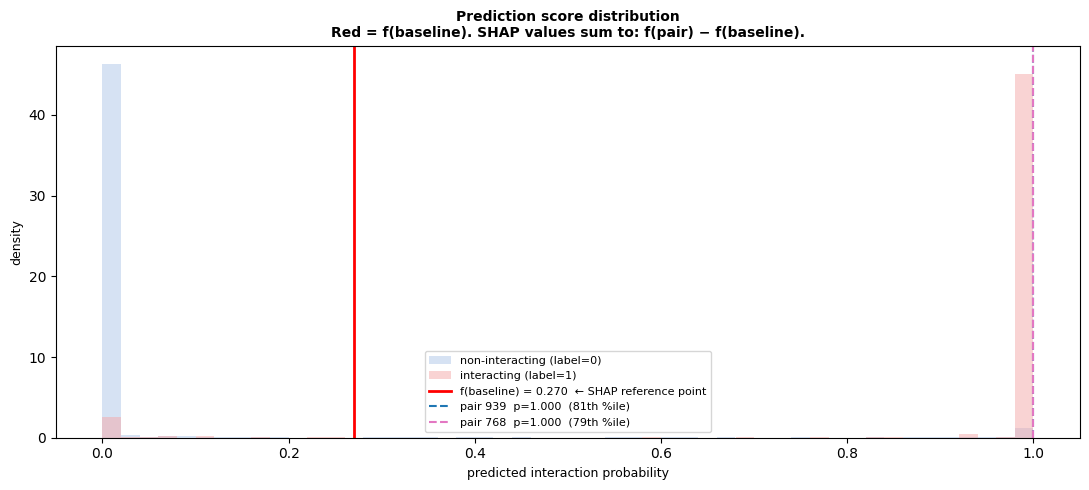

f(baseline [median]) = 0.2700
Dataset mean prediction     = 0.2751
Gap = 0.0051  ✓ acceptable


In [34]:
print("Computing predictions for full test set (batched, no SHAP)...")
BATCH = 256
all_probs = []
with torch.no_grad():
    for start in range(0, len(X_raw), BATCH):
        end   = min(start + BATCH, len(X_raw))
        b_pca = pca_bact.transform(X_raw[start:end, :BACT_DIM].astype(np.float64))
        p_pca = pca_phag.transform(X_raw[start:end, BACT_DIM:].astype(np.float64))
        b_t   = torch.from_numpy(b_pca.astype(np.float32)).to(DEVICE)
        p_t   = torch.from_numpy(p_pca.astype(np.float32)).to(DEVICE)
        logits = model(b_t, p_t)
        all_probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy().tolist())
all_probs   = np.array(all_probs)
true_labels = emb_test_data["interaction_type"].values

with torch.no_grad():
    bl_b = pca_bact.transform(baseline_bact.reshape(1,-1))
    bl_p = pca_phag.transform(baseline_phag.reshape(1,-1))
    logits_bl = model(
        torch.from_numpy(bl_b.astype(np.float32)).to(DEVICE),
        torch.from_numpy(bl_p.astype(np.float32)).to(DEVICE),
    )
    prob_baseline = float(torch.softmax(logits_bl, dim=1)[0, 1])

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(all_probs[true_labels == 0], bins=50, alpha=0.5, color="#aec6e8",
        label="non-interacting (label=0)", density=True)
ax.hist(all_probs[true_labels == 1], bins=50, alpha=0.5, color="#f5a8a8",
        label="interacting (label=1)", density=True)
ax.axvline(prob_baseline, color="red", lw=2,
           label=f"f(baseline) = {prob_baseline:.3f}  ← SHAP reference point")
for pair, color in zip(DIAG_PAIRS, pair_colors):
    idx   = get_pair_idx(pair, emb_test_data)
    prob  = float(all_probs[idx])
    pctile = np.mean(all_probs <= prob)*100
    ax.axvline(prob, color=color, lw=1.5, ls="--",
               label=f"pair {pair['id']}  p={prob:.3f}  ({pctile:.0f}th %ile)")
ax.set_xlabel("predicted interaction probability", fontsize=9)
ax.set_ylabel("density", fontsize=9)
ax.set_title("Prediction score distribution\n"
             "Red = f(baseline). SHAP values sum to: f(pair) − f(baseline).",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("XAI/results/diag_pred_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
gap = abs(prob_baseline - all_probs.mean())
print(f"f(baseline [{BASELINE_MODE}]) = {prob_baseline:.4f}")
print(f"Dataset mean prediction     = {all_probs.mean():.4f}")
print(f"Gap = {gap:.4f}  {'⚠ significant — baseline not a neutral reference' if gap > 0.1 else '✓ acceptable'}")

## Section 11 — Summary Table

Plain-language verdict for baseline quality and each target pair.

In [35]:
print("=" * 72)
print("DIAGNOSTIC SUMMARY")
print("=" * 72)
print(f"\nBaseline mode : {BASELINE_MODE}")
print(f"f(baseline)   : {prob_baseline:.4f}")
print(f"Dataset mean  : {all_probs.mean():.4f}")
gap = abs(prob_baseline - all_probs.mean())
verdict = "⚠  NOT a neutral reference — consider 'random_sample' or 'decoupled' baseline" if gap > 0.15 else "✓  acceptable"
print(f"Gap           : {gap:.4f}  {verdict}")

pct_b_bl = np.mean(mahal_all_b <= mahal_bl_b)*100
pct_p_bl = np.mean(mahal_all_p <= mahal_bl_p)*100
print(f"\nBaseline Mahalanobis:")
print(f"  Bacteria : {mahal_bl_b:.2f}  ({pct_b_bl:.0f}th %ile)  {'⚠ low-density' if pct_b_bl > 80 else '✓'}")
print(f"  Phage    : {mahal_bl_p:.2f}  ({pct_p_bl:.0f}th %ile)  {'⚠ low-density' if pct_p_bl > 80 else '✓'}")

print("\nTarget pairs:")
for row, pair in zip(pair_mahal, DIAG_PAIRS):
    idx    = get_pair_idx(pair, emb_test_data)
    prob   = float(all_probs[idx])
    pctile = np.mean(all_probs <= prob)*100
    issues = []
    if row["bact_pctile"] > 90: issues.append("bacteria embedding outlier")
    if row["phag_pctile"] > 90: issues.append("phage embedding outlier")
    if pctile > 95 or pctile < 5: issues.append("extreme prediction score")
    status = "⚠  " + ", ".join(issues) if issues else "✓  normal"
    print(f"  Pair {pair['id']:>5} (b={pair['bacterium_id']:>5}, p={pair['phage_id']:>5}):  {status}")
    print(f"          pred={prob:.3f} ({pctile:.0f}th %ile) | "
          f"bact Mahal={row['bact_mahal']:.1f} ({row['bact_pctile']:.0f}th %ile) | "
          f"phage Mahal={row['phag_mahal']:.1f} ({row['phag_pctile']:.0f}th %ile)")

DIAGNOSTIC SUMMARY

Baseline mode : median
f(baseline)   : 0.2700
Dataset mean  : 0.2751
Gap           : 0.0051  ✓  acceptable

Baseline Mahalanobis:
  Bacteria : 4201814107.36  (100th %ile)  ⚠ low-density
  Phage    : 6.63  (0th %ile)  ✓

Target pairs:
  Pair   939 (b=  153, p= 2153):  ✓  normal
          pred=1.000 (81th %ile) | bact Mahal=5.8 (50th %ile) | phage Mahal=22.0 (60th %ile)
  Pair   768 (b= 5859, p= 5928):  ✓  normal
          pred=1.000 (79th %ile) | bact Mahal=1.5 (35th %ile) | phage Mahal=20.5 (54th %ile)
